# Machine Learning Mini Project
**Dual-Pipeline Analysis**
* **Part 1:** Continuous Regression (Diamonds Dataset)
* **Part 2:** Multinomial Classification (Water Potability Dataset)

## Step 0: Global Environment Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub

# Preprocessing & Evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, ConfusionMatrixDisplay

# Resampling
from imblearn.over_sampling import SMOTE

# Regression Models
from sklearn.linear_model import LinearRegression, Lasso, Ridge

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

# Set seaborn style for beautiful plots
sns.set_theme(style="whitegrid")

---
# Part 1: Regression Task (Diamonds Dataset)
**Objective:** Predict the continuous numerical price of diamonds based on their physical characteristics.


## Step 1.1: Data Loading (Diamonds)

In [2]:
# Download the dataset
path_diamonds = kagglehub.dataset_download("shivam2503/diamonds")
csv_file_path_diamonds = os.path.join(path_diamonds, "diamonds.csv")

# Load into DataFrame
df_diamonds = pd.read_csv(csv_file_path_diamonds)

# Drop the index column if it exists
if 'Unnamed: 0' in df_diamonds.columns:
    df_diamonds = df_diamonds.drop(columns=['Unnamed: 0'])

print("Diamonds Dataset loaded successfully.")
df_diamonds.head()

Diamonds Dataset loaded successfully.


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


## Step 1.2: Preprocessing & Data Splitting (Diamonds)

In [3]:
# Separate features (X) and target (y)
X_reg = df_diamonds.drop(columns=['price'])
y_reg = df_diamonds['price']

# One-Hot Encoding for categorical features
X_reg_encoded = pd.get_dummies(X_reg, columns=['cut', 'color', 'clarity'], drop_first=True)

# Train-Test Split (80/20)
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X_reg_encoded, y_reg, test_size=0.2, random_state=42)

# Scale continuous features
continuous_features = ['carat', 'depth', 'table', 'x', 'y', 'z']
scaler_reg = StandardScaler()

X_reg_train_scaled = X_reg_train.copy()
X_reg_test_scaled = X_reg_test.copy()

X_reg_train_scaled[continuous_features] = scaler_reg.fit_transform(X_reg_train[continuous_features])
X_reg_test_scaled[continuous_features] = scaler_reg.transform(X_reg_test[continuous_features])

print("Preprocessing complete for Regression dataset.")

Preprocessing complete for Regression dataset.


## Step 1.3: Model Training - Linear Regression

In [4]:
lr_model = LinearRegression()
lr_model.fit(X_reg_train_scaled, y_reg_train)
lr_pred = lr_model.predict(X_reg_test_scaled)

lr_r2 = r2_score(y_reg_test, lr_pred)
lr_mse = mean_squared_error(y_reg_test, lr_pred)

print("Linear Regression Results:")
print(f"R^2 Score: {lr_r2:.4f}")
print(f"Mean Squared Error: {lr_mse:.2f}")

Linear Regression Results:
R^2 Score: 0.9189
Mean Squared Error: 1288705.48


## Step 1.4: Model Training - Lasso Regression (L1)

In [5]:
lasso_model = Lasso(alpha=1.0, random_state=42)
lasso_model.fit(X_reg_train_scaled, y_reg_train)
lasso_pred = lasso_model.predict(X_reg_test_scaled)

lasso_r2 = r2_score(y_reg_test, lasso_pred)
lasso_mse = mean_squared_error(y_reg_test, lasso_pred)

print("Lasso Regression Results:")
print(f"R^2 Score: {lasso_r2:.4f}")
print(f"Mean Squared Error: {lasso_mse:.2f}")

Lasso Regression Results:
R^2 Score: 0.9188
Mean Squared Error: 1291563.35


## Step 1.5: Model Training - Ridge Regression (L2)

In [6]:
ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_reg_train_scaled, y_reg_train)
ridge_pred = ridge_model.predict(X_reg_test_scaled)

ridge_r2 = r2_score(y_reg_test, ridge_pred)
ridge_mse = mean_squared_error(y_reg_test, ridge_pred)

print("Ridge Regression Results:")
print(f"R^2 Score: {ridge_r2:.4f}")
print(f"Mean Squared Error: {ridge_mse:.2f}")

Ridge Regression Results:
R^2 Score: 0.9189
Mean Squared Error: 1288659.50


## Step 1.6: Evaluation - Visual Comparison of Regression Models

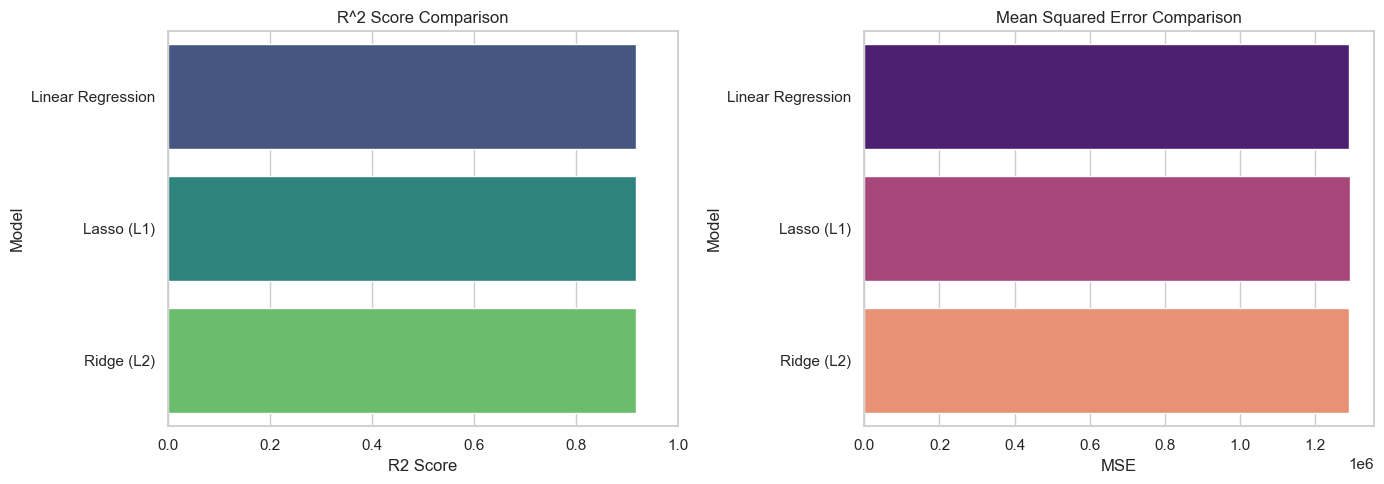

In [7]:
reg_results_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Lasso (L1)', 'Ridge (L2)'],
    'R2 Score': [lr_r2, lasso_r2, ridge_r2],
    'MSE': [lr_mse, lasso_mse, ridge_mse]
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot R2 Score
sns.barplot(x='R2 Score', y='Model', data=reg_results_df, ax=axes[0], palette='viridis')
axes[0].set_title('R^2 Score Comparison')
axes[0].set_xlim(0, 1.0)

# Plot MSE
sns.barplot(x='MSE', y='Model', data=reg_results_df, ax=axes[1], palette='magma')
axes[1].set_title('Mean Squared Error Comparison')

plt.tight_layout()
plt.show()

## Step 1.7: Evaluation - Feature Importance (Diamonds)

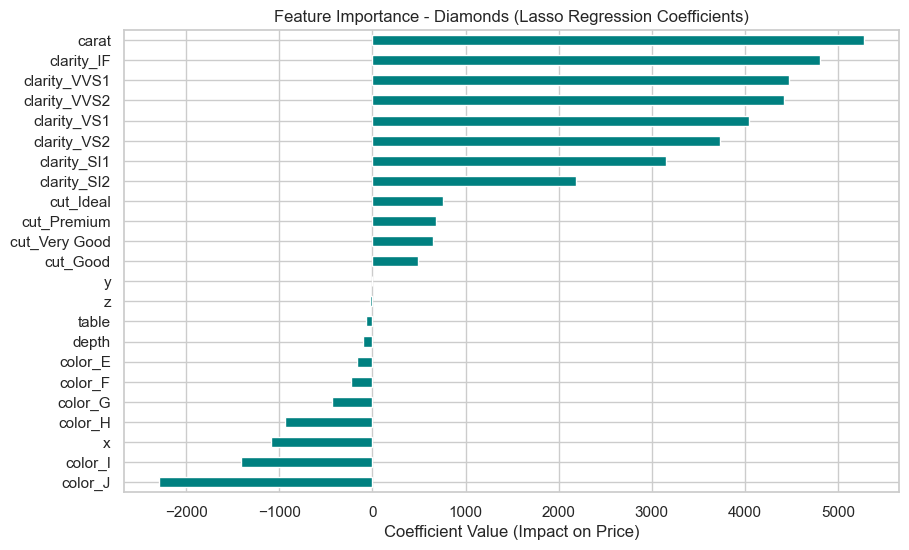

In [8]:
# Using Lasso Coefficients to determine Feature Importance
lasso_coefs = pd.Series(lasso_model.coef_, index=X_reg_train.columns)
plt.figure(figsize=(10, 6))
lasso_coefs.sort_values().plot(kind='barh', color='teal')
plt.title("Feature Importance - Diamonds (Lasso Regression Coefficients)")
plt.xlabel("Coefficient Value (Impact on Price)")
plt.show()

---
# Part 2: Classification Task (Water Potability Dataset)
**Objective:** Predict the discrete water potability class based on chemical attributes.


## Step 2.1: Data Loading & Synthetic Target Creation

In [9]:
# Download the dataset
path_water = kagglehub.dataset_download("adityakadiwal/water-potability")
csv_file_path_water = os.path.join(path_water, "water_potability.csv")

# Load into DataFrame
df_water = pd.read_csv(csv_file_path_water)

# Drop the original 'Potability' column
if 'Potability' in df_water.columns:
    df_water = df_water.drop(columns=['Potability'])

# Create a NEW synthetic target column 'Potability_Class' with 3 classes
temp_ph_for_qcut = df_water['ph'].fillna(df_water['ph'].median())
df_water['Potability_Class'] = pd.qcut(temp_ph_for_qcut, q=3, labels=[0, 1, 2], duplicates='drop').astype(int)

print("Water Potability Dataset loaded.")
print("Target variable distribution:")
print(df_water['Potability_Class'].value_counts())

Water Potability Dataset loaded.
Target variable distribution:
Potability_Class
1    1092
0    1092
2    1092
Name: count, dtype: int64


## Step 2.2: Preprocessing & Data Splitting (Water Potability)

In [10]:
# Separate features and target. We MUST drop 'ph' to prevent Data Leakage!
X_clf = df_water.drop(columns=['Potability_Class', 'ph'])
y_clf = df_water['Potability_Class']

# Train-Test Split (80/20)
X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

# Impute and Scale
imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()

X_clf_train_imputed = imputer.fit_transform(X_clf_train)
X_clf_test_imputed = imputer.transform(X_clf_test)

X_clf_train_scaled = scaler.fit_transform(X_clf_train_imputed)
X_clf_test_scaled = scaler.transform(X_clf_test_imputed)

X_clf_train_scaled = pd.DataFrame(X_clf_train_scaled, columns=X_clf_train.columns)
X_clf_test_scaled = pd.DataFrame(X_clf_test_scaled, columns=X_clf_test.columns)

# Apply SMOTE to balance classes
smote = SMOTE(random_state=42)
X_clf_resampled, y_clf_resampled = smote.fit_resample(X_clf_train_scaled, y_clf_train)

print("Preprocessing complete for Classification dataset.")

Preprocessing complete for Classification dataset.


## Step 2.3: Model Initialization

In [11]:
clf_models = {
    'Logistic Regression (L1)': LogisticRegression(penalty='l1', solver='liblinear', multi_class='ovr', max_iter=1000, random_state=42),
    'Logistic Regression (L2)': LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'XGBoost': XGBClassifier(objective='multi:softprob', num_class=3, eval_metric='mlogloss', random_state=42)
}
clf_results = {}

## Step 2.4: Model Training & Matrix - Logistic Regression (L1)

In [12]:
name = 'Logistic Regression (L1)'
model = clf_models[name]
print(f"Training and evaluating {name}...")

model.fit(X_clf_resampled, y_clf_resampled)
y_pred = model.predict(X_clf_test_scaled)

accuracy = accuracy_score(y_clf_test, y_pred)
precision = precision_score(y_clf_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_clf_test, y_pred, average='weighted')
f1 = f1_score(y_clf_test, y_pred, average='weighted')

clf_results[name] = {
    'Accuracy': accuracy, 
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1
}

print(f"Accuracy: {accuracy:.4f}")
print(f"F1-Score (Weighted): {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_clf_test, y_pred, target_names=['Unsafe', 'Marginal', 'Safe'], zero_division=0))

Training and evaluating Logistic Regression (L1)...
Accuracy: 0.3720
F1-Score (Weighted): 0.3487

Classification Report:
              precision    recall  f1-score   support

      Unsafe       0.38      0.55      0.45       218
    Marginal       0.31      0.14      0.19       219
        Safe       0.39      0.43      0.41       219

    accuracy                           0.37       656
   macro avg       0.36      0.37      0.35       656
weighted avg       0.36      0.37      0.35       656



<Figure size 400x300 with 0 Axes>

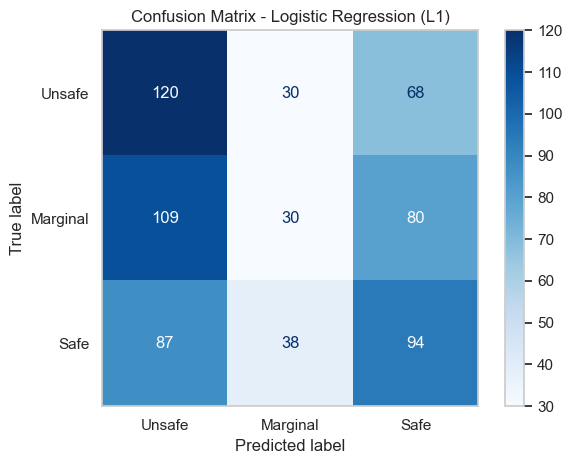

In [13]:
# Confusion Matrix
plt.figure(figsize=(4, 3))
cmp = ConfusionMatrixDisplay.from_predictions(y_clf_test, y_pred, 
                                              display_labels=['Unsafe', 'Marginal', 'Safe'], 
                                              cmap=plt.cm.Blues)
cmp.ax_.set_title(f"Confusion Matrix - {name}")
plt.grid(False) # Turn off grid for heatmap
plt.tight_layout()
plt.show()

## Step 2.5: Model Training & Matrix - Logistic Regression (L2)

In [14]:
name = 'Logistic Regression (L2)'
model = clf_models[name]
print(f"Training and evaluating {name}...")

model.fit(X_clf_resampled, y_clf_resampled)
y_pred = model.predict(X_clf_test_scaled)

accuracy = accuracy_score(y_clf_test, y_pred)
precision = precision_score(y_clf_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_clf_test, y_pred, average='weighted')
f1 = f1_score(y_clf_test, y_pred, average='weighted')

clf_results[name] = {
    'Accuracy': accuracy, 
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1
}

print(f"Accuracy: {accuracy:.4f}")
print(f"F1-Score (Weighted): {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_clf_test, y_pred, target_names=['Unsafe', 'Marginal', 'Safe'], zero_division=0))

Training and evaluating Logistic Regression (L2)...
Accuracy: 0.3689
F1-Score (Weighted): 0.3521

Classification Report:
              precision    recall  f1-score   support

      Unsafe       0.38      0.53      0.44       218
    Marginal       0.33      0.17      0.22       219
        Safe       0.38      0.41      0.39       219

    accuracy                           0.37       656
   macro avg       0.36      0.37      0.35       656
weighted avg       0.36      0.37      0.35       656



<Figure size 400x300 with 0 Axes>

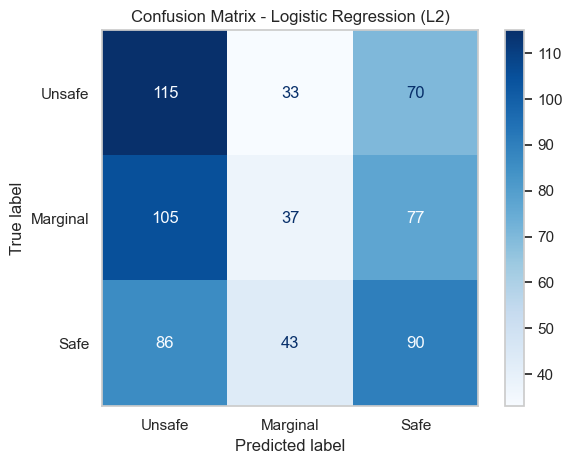

In [15]:
# Confusion Matrix
plt.figure(figsize=(4, 3))
cmp = ConfusionMatrixDisplay.from_predictions(y_clf_test, y_pred, 
                                              display_labels=['Unsafe', 'Marginal', 'Safe'], 
                                              cmap=plt.cm.Blues)
cmp.ax_.set_title(f"Confusion Matrix - {name}")
plt.grid(False) # Turn off grid for heatmap
plt.tight_layout()
plt.show()

## Step 2.6: Model Training & Matrix - Decision Tree

In [16]:
name = 'Decision Tree'
model = clf_models[name]
print(f"Training and evaluating {name}...")

model.fit(X_clf_resampled, y_clf_resampled)
y_pred = model.predict(X_clf_test_scaled)

accuracy = accuracy_score(y_clf_test, y_pred)
precision = precision_score(y_clf_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_clf_test, y_pred, average='weighted')
f1 = f1_score(y_clf_test, y_pred, average='weighted')

clf_results[name] = {
    'Accuracy': accuracy, 
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1
}

print(f"Accuracy: {accuracy:.4f}")
print(f"F1-Score (Weighted): {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_clf_test, y_pred, target_names=['Unsafe', 'Marginal', 'Safe'], zero_division=0))

Training and evaluating Decision Tree...
Accuracy: 0.3338
F1-Score (Weighted): 0.3320

Classification Report:
              precision    recall  f1-score   support

      Unsafe       0.36      0.34      0.35       218
    Marginal       0.30      0.26      0.28       219
        Safe       0.34      0.40      0.37       219

    accuracy                           0.33       656
   macro avg       0.33      0.33      0.33       656
weighted avg       0.33      0.33      0.33       656



<Figure size 400x300 with 0 Axes>

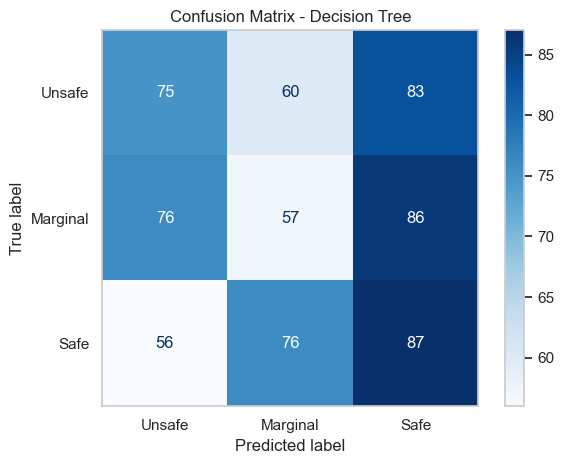

In [17]:
# Confusion Matrix
plt.figure(figsize=(4, 3))
cmp = ConfusionMatrixDisplay.from_predictions(y_clf_test, y_pred, 
                                              display_labels=['Unsafe', 'Marginal', 'Safe'], 
                                              cmap=plt.cm.Blues)
cmp.ax_.set_title(f"Confusion Matrix - {name}")
plt.grid(False) # Turn off grid for heatmap
plt.tight_layout()
plt.show()

## Step 2.7: Model Training & Matrix - Random Forest

In [18]:
name = 'Random Forest'
model = clf_models[name]
print(f"Training and evaluating {name}...")

model.fit(X_clf_resampled, y_clf_resampled)
y_pred = model.predict(X_clf_test_scaled)

accuracy = accuracy_score(y_clf_test, y_pred)
precision = precision_score(y_clf_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_clf_test, y_pred, average='weighted')
f1 = f1_score(y_clf_test, y_pred, average='weighted')

clf_results[name] = {
    'Accuracy': accuracy, 
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1
}

print(f"Accuracy: {accuracy:.4f}")
print(f"F1-Score (Weighted): {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_clf_test, y_pred, target_names=['Unsafe', 'Marginal', 'Safe'], zero_division=0))

Training and evaluating Random Forest...
Accuracy: 0.3476
F1-Score (Weighted): 0.3451

Classification Report:
              precision    recall  f1-score   support

      Unsafe       0.38      0.44      0.41       218
    Marginal       0.34      0.30      0.32       219
        Safe       0.32      0.30      0.31       219

    accuracy                           0.35       656
   macro avg       0.35      0.35      0.35       656
weighted avg       0.34      0.35      0.35       656



<Figure size 400x300 with 0 Axes>

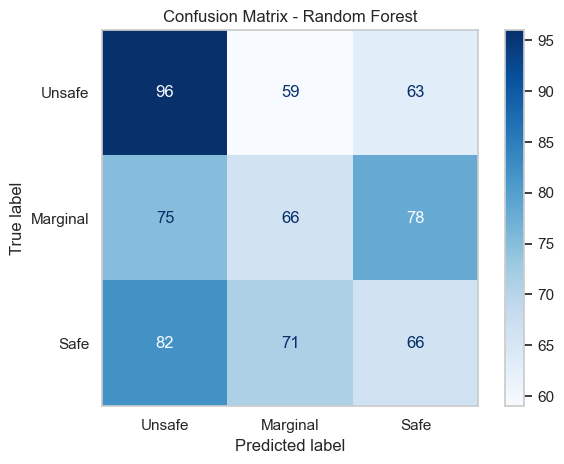

In [19]:
# Confusion Matrix
plt.figure(figsize=(4, 3))
cmp = ConfusionMatrixDisplay.from_predictions(y_clf_test, y_pred, 
                                              display_labels=['Unsafe', 'Marginal', 'Safe'], 
                                              cmap=plt.cm.Blues)
cmp.ax_.set_title(f"Confusion Matrix - {name}")
plt.grid(False) # Turn off grid for heatmap
plt.tight_layout()
plt.show()

## Step 2.8: Model Training & Matrix - K-Nearest Neighbors

In [20]:
name = 'K-Nearest Neighbors'
model = clf_models[name]
print(f"Training and evaluating {name}...")

model.fit(X_clf_resampled, y_clf_resampled)
y_pred = model.predict(X_clf_test_scaled)

accuracy = accuracy_score(y_clf_test, y_pred)
precision = precision_score(y_clf_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_clf_test, y_pred, average='weighted')
f1 = f1_score(y_clf_test, y_pred, average='weighted')

clf_results[name] = {
    'Accuracy': accuracy, 
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1
}

print(f"Accuracy: {accuracy:.4f}")
print(f"F1-Score (Weighted): {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_clf_test, y_pred, target_names=['Unsafe', 'Marginal', 'Safe'], zero_division=0))

Training and evaluating K-Nearest Neighbors...
Accuracy: 0.3674
F1-Score (Weighted): 0.3620

Classification Report:
              precision    recall  f1-score   support

      Unsafe       0.37      0.50      0.42       218
    Marginal       0.32      0.32      0.32       219
        Safe       0.44      0.28      0.34       219

    accuracy                           0.37       656
   macro avg       0.38      0.37      0.36       656
weighted avg       0.38      0.37      0.36       656



<Figure size 400x300 with 0 Axes>

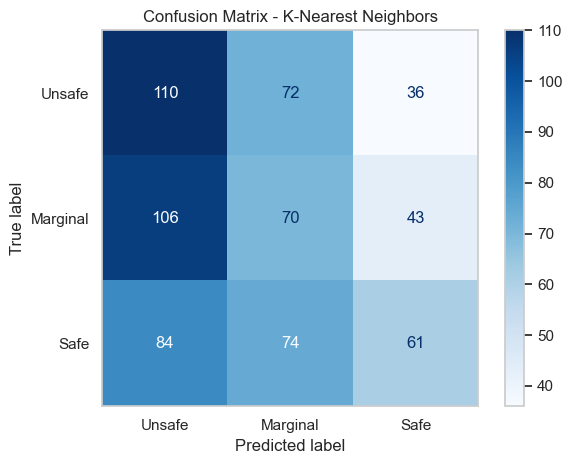

In [21]:
# Confusion Matrix
plt.figure(figsize=(4, 3))
cmp = ConfusionMatrixDisplay.from_predictions(y_clf_test, y_pred, 
                                              display_labels=['Unsafe', 'Marginal', 'Safe'], 
                                              cmap=plt.cm.Blues)
cmp.ax_.set_title(f"Confusion Matrix - {name}")
plt.grid(False) # Turn off grid for heatmap
plt.tight_layout()
plt.show()

## Step 2.9: Model Training & Matrix - XGBoost

In [22]:
name = 'XGBoost'
model = clf_models[name]
print(f"Training and evaluating {name}...")

model.fit(X_clf_resampled, y_clf_resampled)
y_pred = model.predict(X_clf_test_scaled)

accuracy = accuracy_score(y_clf_test, y_pred)
precision = precision_score(y_clf_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_clf_test, y_pred, average='weighted')
f1 = f1_score(y_clf_test, y_pred, average='weighted')

clf_results[name] = {
    'Accuracy': accuracy, 
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1
}

print(f"Accuracy: {accuracy:.4f}")
print(f"F1-Score (Weighted): {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_clf_test, y_pred, target_names=['Unsafe', 'Marginal', 'Safe'], zero_division=0))

Training and evaluating XGBoost...
Accuracy: 0.3384
F1-Score (Weighted): 0.3380

Classification Report:
              precision    recall  f1-score   support

      Unsafe       0.37      0.38      0.37       218
    Marginal       0.31      0.30      0.30       219
        Safe       0.34      0.34      0.34       219

    accuracy                           0.34       656
   macro avg       0.34      0.34      0.34       656
weighted avg       0.34      0.34      0.34       656



<Figure size 400x300 with 0 Axes>

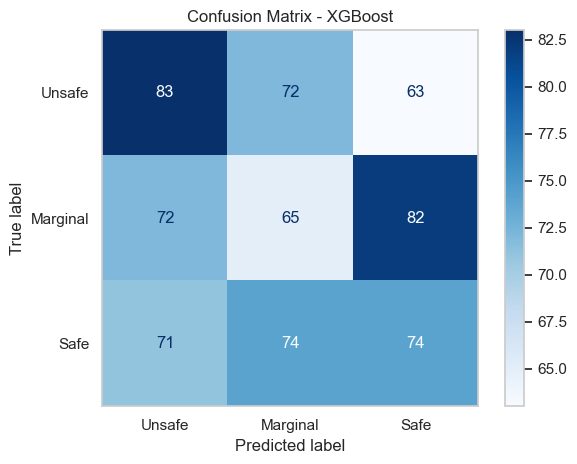

In [23]:
# Confusion Matrix
plt.figure(figsize=(4, 3))
cmp = ConfusionMatrixDisplay.from_predictions(y_clf_test, y_pred, 
                                              display_labels=['Unsafe', 'Marginal', 'Safe'], 
                                              cmap=plt.cm.Blues)
cmp.ax_.set_title(f"Confusion Matrix - {name}")
plt.grid(False) # Turn off grid for heatmap
plt.tight_layout()
plt.show()

## Step 2.10: Evaluation - Visual Comparison (F1-Score)

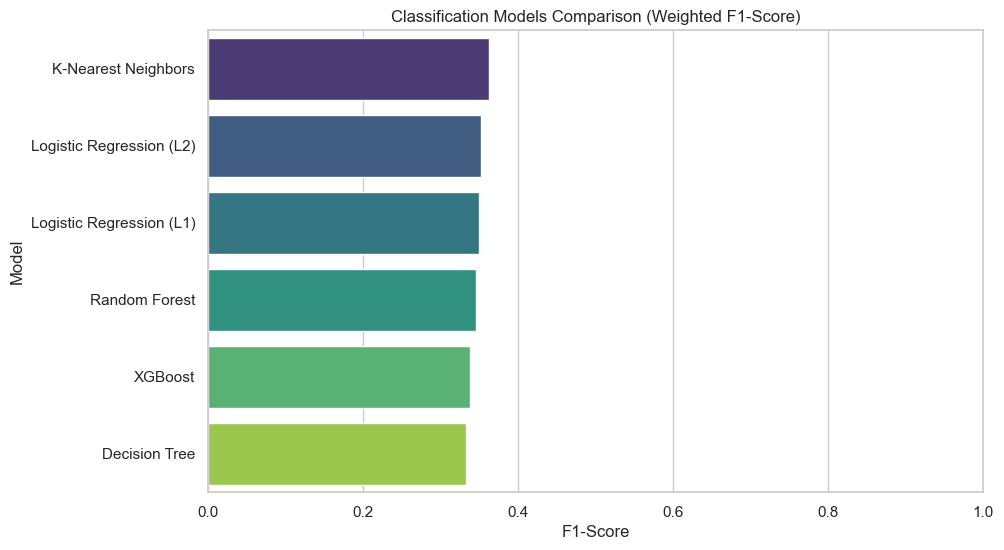

,Model,Accuracy,Precision,Recall,F1-Score
4,K-Nearest Neighbors,0.367378,0.375498,0.367378,0.362032
1,Logistic Regression (L2),0.368902,0.360977,0.368902,0.352054
0,Logistic Regression (L1),0.371951,0.358067,0.371951,0.348687
3,Random Forest,0.347561,0.344955,0.347561,0.345096
5,XGBoost,0.338415,0.337693,0.338415,0.337978
2,Decision Tree,0.333841,0.332454,0.333841,0.331953


In [24]:
# Compare Classification Models
results_df = pd.DataFrame(clf_results).T.reset_index()
results_df.columns = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score']
results_df = results_df.sort_values(by='F1-Score', ascending=False)

# Bar plot for F1-Score
plt.figure(figsize=(10, 6))
sns.barplot(x='F1-Score', y='Model', data=results_df, palette='viridis')
plt.title("Classification Models Comparison (Weighted F1-Score)")
plt.xlim(0, 1.0)
plt.show()

# Show tabular results
results_df

## Step 2.11: Evaluation - Feature Importance (Random Forest)

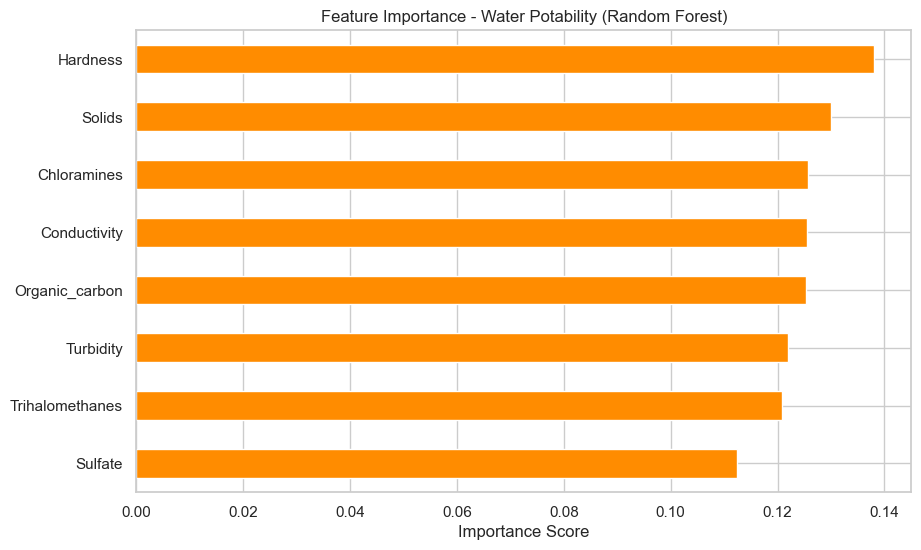

In [25]:
# Using Random Forest to determine Feature Importance
rf_importances = pd.Series(clf_models['Random Forest'].feature_importances_, index=X_clf_train.columns)
plt.figure(figsize=(10, 6))
rf_importances.sort_values().plot(kind='barh', color='darkorange')
plt.title("Feature Importance - Water Potability (Random Forest)")
plt.xlabel("Importance Score")
plt.show()

## Step 2.12: Evaluation - Macro-Average ROC Curves (One-vs-Rest)
Plotting the macro-average Receiver Operating Characteristic (ROC) curves for all classification models to evaluate their multi-class discriminatory power.

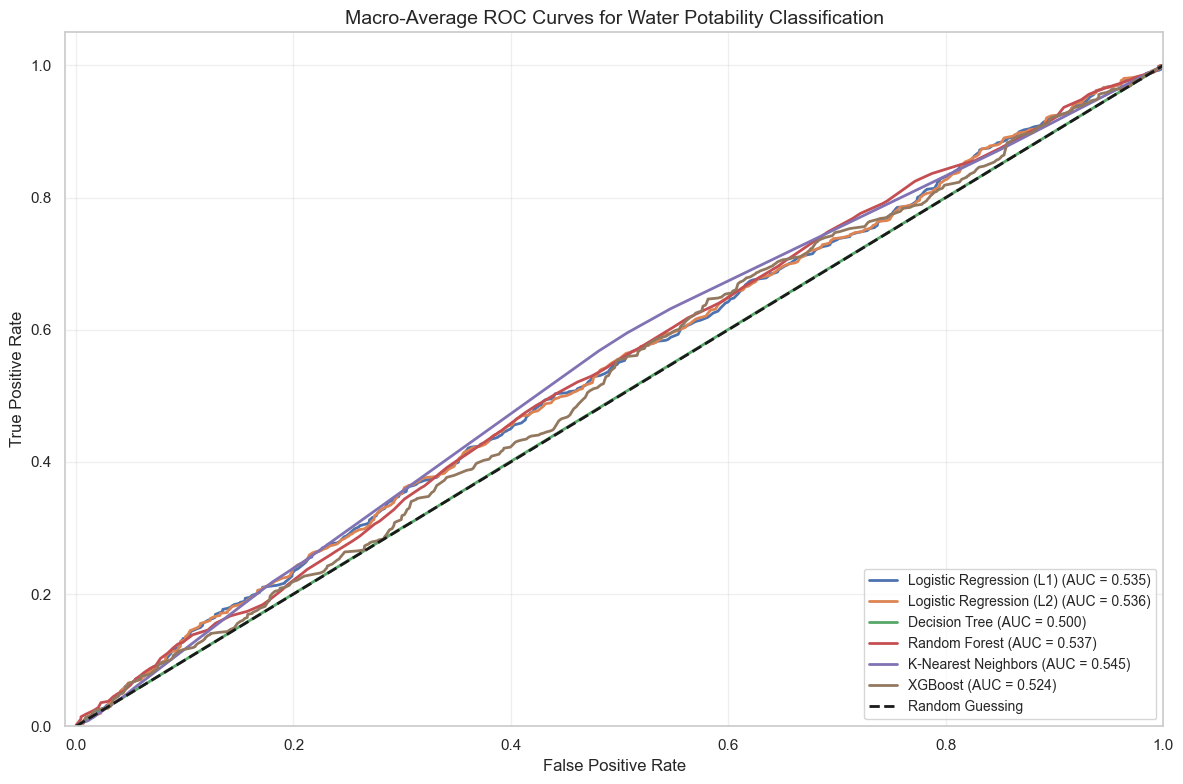

In [26]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Binarize the test labels for One-vs-Rest ROC evaluation
y_test_bin = label_binarize(y_clf_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(12, 8))

for name, model in clf_models.items():
    if hasattr(model, "predict_proba"):
        # Get probability scores
        y_score = model.predict_proba(X_clf_test_scaled)
        
        fpr = dict()
        tpr = dict()
        
        # Calculate ROC for each class
        for i in range(n_classes):
            fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
            
        # Aggregate all false positive rates
        all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
        
        # Interpolate all ROC curves at these points
        mean_tpr = np.zeros_like(all_fpr)
        for i in range(n_classes):
            mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
            
        # Average to get macro-average TPR
        mean_tpr /= n_classes
        
        # Calculate macro AUC
        macro_auc = auc(all_fpr, mean_tpr)
        
        # Plot
        plt.plot(all_fpr, mean_tpr,
                 label=f'{name} (AUC = {macro_auc:.3f})',
                 linewidth=2)

# Plot random guessing baseline
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guessing')

plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Macro-Average ROC Curves for Water Potability Classification', fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()